In [1]:
from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set, elements
import os
from data import items, item_sets
import json

In [2]:
from datetime import datetime
config = {
            "optimizer" : {
                "path" : f"outputs/{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}/sacri-omni-crit-absweapon",
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 1/3 of population size
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              6980, # Vulbis
                              13344, # Dolmanax
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                        # 14093, # Botas kuko
                        # 18718, # Escudo kuko
                        # 14092, # Anillo kuko
                        # 8993, # Espada maldita
                        # 7754, # Dofus ocre
                    ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 6,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        29: {
                            "target": 80,  # Crit
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        9: {
                            "target": 4000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        }
                    },
                    "upper": {}
                },

                "level_offset": 10,  # Level offset for items
                "objective": "weapon",  # Objective to optimize, can be "weapon" or "elements"
                "normalize_by_apcost" : False # If False, only care about absolute damage regardless of AP cost
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    8:1 # Exo MP
                    },  
                "distributed_points": {
                    9: 595,  # Vitality
                },
                "elements" : [
                    36, # Agility,
                    22, # Chance
                    13, # Intelligence
                    45  # Strength
                ],
                "melee" : True,
                "ranged" : False
            }
        }

# Insert a list of initial user guesses, e.g., current set to use in optimization
initial_options = [
    [
    8993, # Espada
    13641, 13642, # Noai
    14161, 14162, 14169, # Charlatan
    14092, 14093, 18718, # Kuko
    13673, # Lokulto
    739, 694, 7754, 737, 7043, 17078 # Dofus
    ]
]
config["optimizer"]["initial_options"] = initial_options

if not os.path.exists(config["optimizer"]["path"]):
    os.makedirs(config["optimizer"]["path"], exist_ok=True)

with open(config["optimizer"]["path"] + '/config.json', 'w') as file:
    json.dump(config, file, indent=4)

In [3]:
import pandas as pd

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
    dct[k].update({i:j for i,j in v['type'].items() if i not in dct[k]})
Items = pd.DataFrame.from_dict(dct, orient='index')

In [4]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2979
Total item sets: 161
Total pools:
   16 with sizes [73, 75, 82, 82, 65, 83, 46, 93, 72, 1416, 318, 318, 318, 318, 318, 318]
Total combinations: 10^34.95


In [ ]:
solutions = opt.optimize(islands = 16,
                          max_workers = 4)

/Users/jdtibochab/other/dofus-set-optimizer/.venv/lib/python3.12/site-packages/pygad/utils/validation.py:1914: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/other/dofus-set-optimizer/.venv/lib/python3.12/site-packages/pygad/utils/validation.py:1914: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/other/dofus-set-optimizer/.venv/lib/python3.12/site-packages/pygad/utils/validation.py:1

## Analysis

In [ ]:
from analysis import Analyzer
analyzer = Analyzer(opt, solutions)
analyzer.run_analysis()

Number of candidate solutions: 171


In [ ]:
analyzer.report_extended_results()

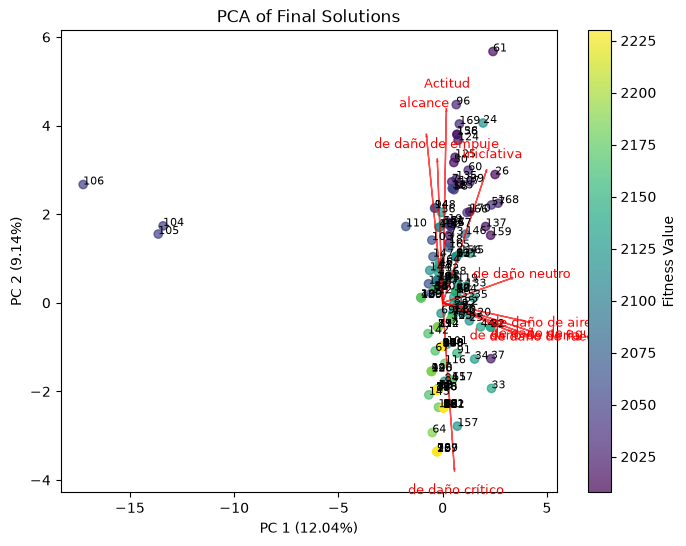

In [ ]:
analyzer.plot_pca()

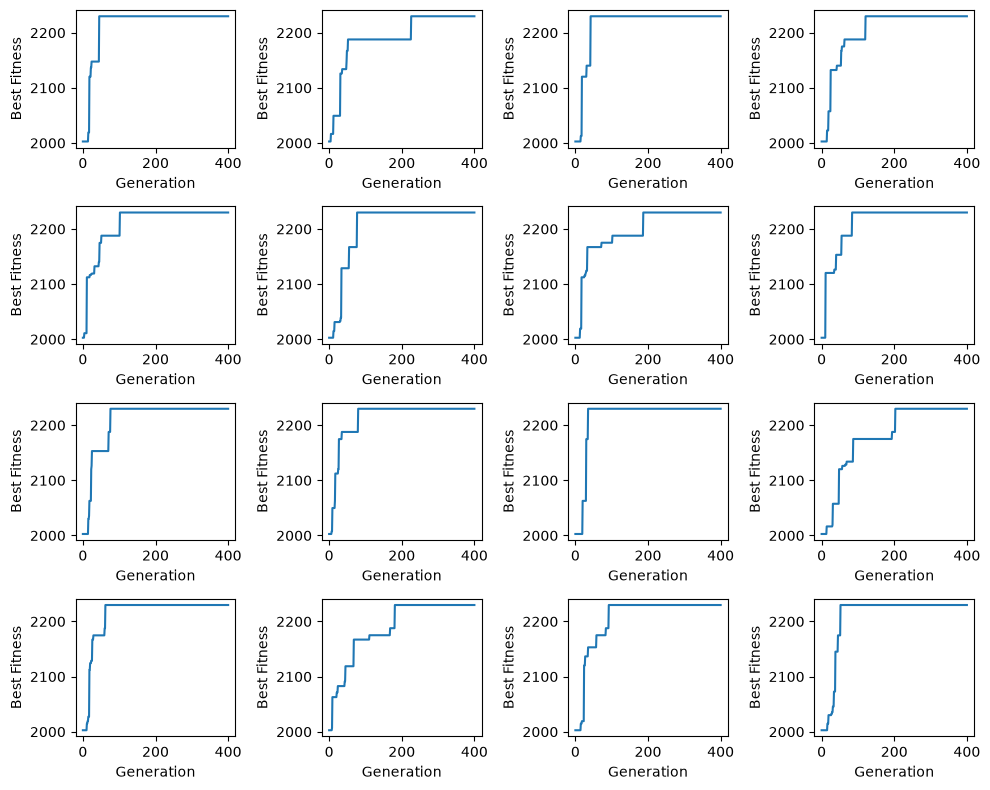

In [ ]:
analyzer.report_generations()

In [ ]:
assert False

In [ ]:
# Current
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 18043 # Dofus
                 ],
                 opt)
chr.fitness, chr.get_final_damage("weapon")

In [ ]:
Items.loc[chr.chromosome]

In [ ]:
chr.totals_summary()

In [ ]:
Items[Items["name"].str.contains("abisal",case=False)]

,name,set,level
18042,Valva abisal,NaN,1
34340,Luz abisal,NaN,200
18043,Dofus abisal,NaN,180
34419,Tesoro abisal,NaN,200
20162,Metal abisal,NaN,200


In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary()

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)